In [38]:
import Pkg; Pkg.activate("../")
using NMRlab
using FFTW
using Plots

  Activating project at `~/Source/NMRlab`


In [8]:
n=14
hc = GenerateFIDs.HamiltonianGenerator("hamiltonian.toml")
H=hc(n)

16384×16384 SparseArrays.SparseMatrixCSC{Float64, Int64} with 622592 stored entries:
⎡⣿⣿⣾⣦⡀⣷⣄⠀⠀⠀⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠺⣿⣿⣿⣿⣮⡋⢳⣄⠀⢮⡋⢳⣄⠀⠀⠀⠀⠀⠀⢮⡛⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⢤⣬⡻⣿⠿⣧⣽⣮⡻⠳⣄⠙⠮⠻⠳⣄⠀⠀⠀⠀⣄⠙⠎⠻⢷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠙⢯⣈⡳⣿⣿⣿⣿⣦⡈⠳⣄⠀⠀⡻⡷⣄⠀⠀⠈⠳⣄⠀⢈⡻⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠙⢿⡊⠻⣿⣿⣿⡆⠀⠈⠳⣄⠙⢦⡸⣷⣄⠀⠀⠈⠳⣄⠙⢦⡻⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠙⢿⡮⠳⣄⠙⢦⡈⠈⠉⣿⣿⣾⣦⡈⣷⣄⠉⠈⠈⠳⣄⠀⠀⠈⠀⠀⠁⠈⠹⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢶⣮⡃⠀⠙⢦⡀⠺⣿⣿⣿⣿⣮⡋⢳⣄⠀⠀⠈⠳⣄⠀⠀⠀⠀⠀⠐⢮⡛⣷⣄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⢦⣤⡠⣄⠙⢦⣬⡻⣿⠿⣧⣽⣮⡻⠳⠀⠀⠀⠈⠳⣄⠀⠀⠀⠠⣄⠙⠎⠻⢷⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠙⢯⣈⡳⡄⠙⢯⣈⡳⣿⣿⣿⣿⣦⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠈⠳⣄⠀⢈⡻⣷⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⡂⠀⠀⠙⢿⡊⠻⣿⣿⣿⠀⠀⠀⠀⠀⠀⠀⠈⠳⣄⠀⠀⠈⠳⣄⠙⢦⡻⣷⣄⎥
⎢⠙⢿⣮⠳⣄⠙⢦⡀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠀⠀⣿⣿⣿⣦⡨⣷⣄⠀⠀⠨⣷⣄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠙⢿⣮⡁⠀⠙⢦⡀⠀⠀⠙⢦⡀⠀⠀⠀⠀⠀⠻⣿⣿⣿⣿⢮⡉⣳⣄⠘⢮⡉⣳⣄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠙⢷⣦⡰⣄⠙⠂⠀⠀⠀⠙⢦⡀⠀⠀⠀⢦⣮⡻⣟⢻⣶⣿⣮⡛⠳⣄⠙⠊⠛⠳⣄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠙⢿⣬⡳⠄⠀⠀⠀⠀⠀⠙⢦⡀⠀⠀⠙⢧⣨⡻⣿⣿⣿⣿⡦⠈⠳⣄⠀⢨⡻⠷⣄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣆⡀⢀⠀⠀⡀⠀⠀⠙⢦⡀⡀⣀⠙⢿⡈⠻⡿⣿⣿⣀⡀⡈⠳⣄⠙⢦⡺⣷⣄⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣮⠳⣄⠙⢦⡀⠀⠀⠙⢿⡎⠳⣄⠙⢦⡀⠀⠸⣿⣿⣿⣦⡨⣷⣄⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣮⡁⠀⠙⢦⡀⠀⠀⠙⢾⣮⠀⠀⠙⢦⡈⠻⣿⣿⣿⣿⢮⡉⣳⣄⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢷⣦⡰⣄⠙⠀⠀⠀⠀⠙⢦⣦⡲⣄⠙⢦⣮⡻⣟⢻⣶⣿⣮⡛⠓⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⣬⡳⠀⠀⠀⠀⠀⠀⠙⢧⣨⡳⠀⠙⢧⣨⡻⣿⣿⣿⣿⡦⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⠀⠀⠀⠀⠀⠀⠀⠀⠙⢿⠀⠀⠀⠙⢿⠈⠻⡿⣿⣿⎦

In [9]:
rho0=sum(SpinSim.SpinOp(n,SpinSim.Sx,k) for k=1:n)
Fp=sum(SpinSim.SpinOp(n,SpinSim.Sp,k) for k=1:n)

freqs,ints = SpinSim.Spectrum(rho0,H,Fp)

([-3108.890470465958, -3444.475207916912, -4878.376691815101, -5316.777625589137, -6663.455110356808, -10085.577867727785, -11603.932540330454, 3491.4442556607755, 8216.555832340498, 11627.161332492426  …  -3291.0576020411027, -6033.173489745597, -4688.132225953406, 3312.51667592959, -6030.843265853495, -5998.98817583685, -5205.64717930834, -5071.340209409267, -3505.4267664543004, -2713.516071529055], ComplexF64[0.4265600585572994 - 0.0im, 0.58407277821621 + 0.0im, 0.6995904320248818 - 0.0im, 0.30101113705376037 - 0.0im, 0.5157788215472915 - 0.0im, 0.4976015785845701 - 0.0im, 0.4412727419930578 + 0.0im, 0.48427322120961935 + 0.0im, 0.4848029208328902 + 0.0im, 0.5318552110111957 - 0.0im  …  0.5792099254116054 - 0.0im, 0.4815735117011868 - 0.0im, 0.44250121701278694 - 0.0im, 0.4975073458974427 + 0.0im, 0.5283089347780336 + 0.0im, 0.4756795078595249 + 0.0im, 0.9087542953494009 - 0.0im, 0.01444887838333249 + 0.0im, 0.012924061239639186 + 0.0im, 0.41687047628798213 - 0.0im])

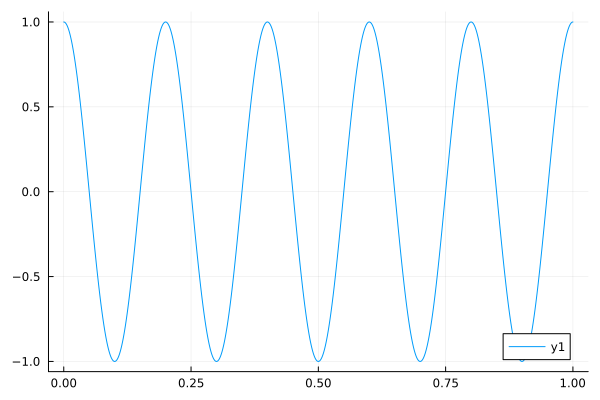

In [46]:
t=range(0.0,1.0,step=0.000025)
plot(t,real(exp.(im*2pi*5.0*t)))

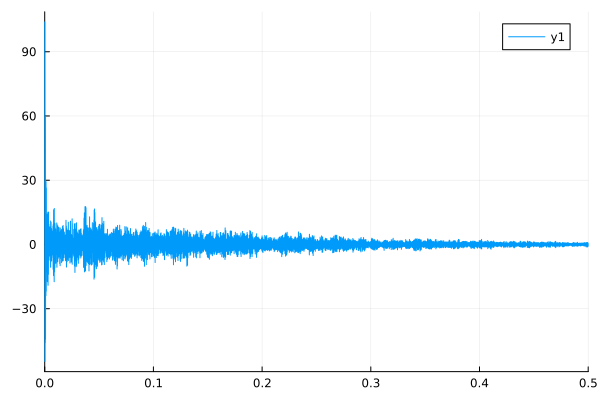

In [47]:
S=sum([i*exp.(im*2*pi*f*t) for (f,i) in zip(freqs,ints)]) .* exp.(-5*t)
plot(t,real(S),xlim=[0,0.5])

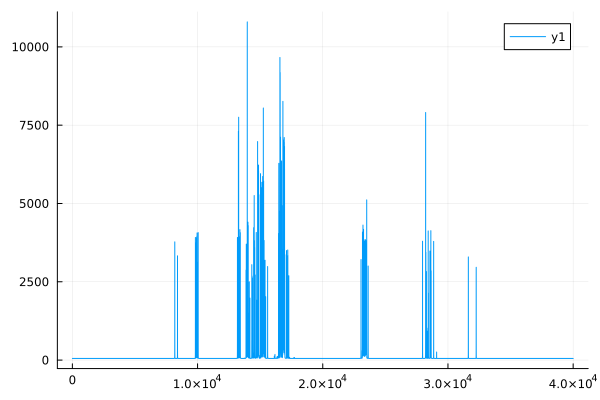

In [48]:
plot(S |> fft |> fftshift |> real)

In [ ]:
GenerateFIDs.generateBatch("generateFIDs.toml")